In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def load_thermo(path):
    # Read header to find column titles
    titles = []
    with open(path) as f:
        for line in f:
            if line.startswith('#') and ':' in line:
                titles = [t.split(':',1)[1].strip()
                          for t in line.lstrip('#').split('  ')
                          if ':' in t and t.strip()]
    d = np.loadtxt(path)
    kappa = -np.log(np.clip(d[:, 5], 1e-300, 1.0))

    # tau_reio: optical depth contribution from z < 50
    z_arr = d[:, 1]
    z_cut = 50.0
    idx_cut = np.argmin(np.abs(z_arr - z_cut))
    tau_reio = kappa[idx_cut] - kappa[0]

    out = {
        'a':        d[:, 0],
        'z':        d[:, 1],
        'tau':      d[:, 2],
        'xe':       d[:, 3],
        'dkappa':   d[:, 4],
        'expmk':    d[:, 5],
        'g':        d[:, 6],
        'Tb':       d[:, 7],
        'dTb':      d[:, 8],
        'wb':       d[:, 9],
        'cb2':      d[:, 10],
        'kappa_b':  d[:, 11],
        'kappa':    kappa,
        'tau_reio': tau_reio,
    }
    # x_H column only present for jwst_popIII runs
    if 'x_H' in titles:
        out['x_H'] = d[:, titles.index('x_H')]
    return out

runs = {
    'default':      load_thermo('../output/default00_thermodynamics.dat'),
    'jwst_default': load_thermo('../output/jwst_default00_thermodynamics.dat'),
    # 'jwst_default2': load_thermo('../output/jwst_default01_thermodynamics.dat'),
    # 'jwst_default3': load_thermo('../output/jwst_default02_thermodynamics.dat'),
}

for label, r in runs.items():
    print(f'{label}: tau_reio = {r["tau_reio"]:.6f}')


default: tau_reio = 0.054459
jwst_default: tau_reio = 0.048521


NameError: name 'runs' is not defined

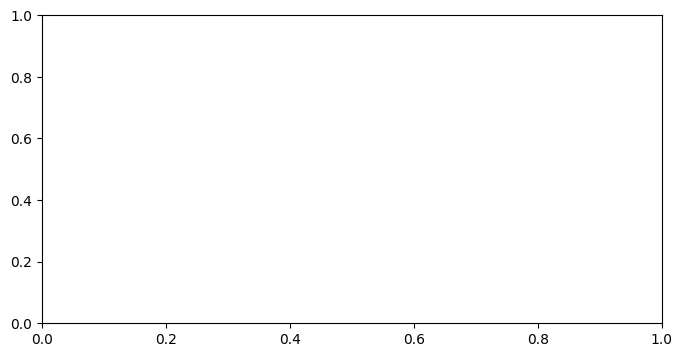

In [3]:
# Ionization fraction x_e(z) — full range
fig, ax = plt.subplots(figsize=(8, 4))
for label, r in runs.items():
    print(r["tau_reio"])
    ax.plot(r['z'], r['xe'], label=label)
ax.set_xlabel('z')
ax.set_ylabel(r'$x_e$')
ax.set_title('Ionization fraction')
# ax.set_yscale('log')
ax.set_xlim(0, 10)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Ionization fraction — reionization epoch zoom
fig, ax = plt.subplots(figsize=(8, 4))
for label, r in runs.items():
    ax.plot(r['z'], r['xe'], label=label)
ax.set_xlabel('z')
ax.set_ylabel(r'$x_e$')
ax.set_title('Ionization fraction — reionization epoch')
ax.set_xlim(0, 30)
ax.set_ylim(0, 1.4)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Optical depth kappa(z)
z_cut = 50.0

fig, ax = plt.subplots(figsize=(8, 4))
for label, r in runs.items():
    idx_cut = np.argmin(np.abs(r['z'] - z_cut))
    tau_reio = r['kappa'][idx_cut] - r['kappa'][0]
    print(f'{label}: tau_reio (z < {z_cut:.0f}) = {tau_reio:.6f}')
    ax.plot(r['z'], r['kappa'], label=label)

ax.axvline(z_cut, color='gray', linestyle='--', label=f'z = {z_cut:.0f}')
ax.set_xlabel('z')
ax.set_ylabel(r'$\kappa(z)$')
ax.set_title('Optical depth')
ax.set_xscale('log')
ax.set_xlim(1, max(r['z'].max() for r in runs.values()))
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# x_H(z) — only for runs that have the column
fig, ax = plt.subplots(figsize=(8, 4))
for label, r in runs.items():
    if 'x_H' in r:
        ax.plot(r['z'], r['x_H'], label=label)
ax.set_xlabel('z')
ax.set_ylabel(r'$x_{\rm HII}$')
ax.set_title('Hydrogen ionization fraction (JWST pop-III ODE)')
ax.set_xlim(0, 30)
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.show()
